In [2]:
from scipy.integrate import solve_ivp
import numpy as np

In [3]:
def solve_problem(r0,Y0,extremo, sys):
    # Integración hacia adelante (de R a R + extremo (el extremo se puede cambiar)) usando RK45 se puede cambiar a otros con mas precisión
    # La estructura de la solucion es un vector que contiene:
    # sol_forward[0] es el tiempo en el que se corre la solución
    # sol_forward[1] es la u[t]
    # sol_forward[2] es la u'[t]
    sol_forward = solve_ivp(sys, [r0, r0+extremo], Y0, method='RK45',rtol=1e-10, atol=1e-15)

    # Integración hacia adelante (de R-extremo a R ) usando RK45 
    sol_backward = solve_ivp(sys, [r0, r0-extremo], Y0, method='RK45',rtol=1e-10, atol=1e-15)


    # Combinar las soluciones de los dos tramos en un solo conjunto de puntos
    # (invertimos la solución hacia atrás para que vaya de r_0-extremo a r0)
    t_forward,u_forward,pu_forward = sol_forward.t, sol_forward.y[0], sol_forward.y[1]
    t_backward,u_backward, pu_backward   = sol_backward.t,sol_backward.y[0], sol_backward.y[1]
    
    # Invertir la parte hacia atrás 
    # Ya que nos viene dado del punto R a R - extremo entonces queremos darle la vuelta
    t_backward_rev = t_backward[::-1]
    u_backward_rev = u_backward[::-1]
    pu_backward_rev = pu_backward[::-1]

    # Eliminar el punto duplicado en r=R0 para unir las soluciones sin repetir
    if abs(t_backward_rev[-1] - r0) < 1e-12:
        t_backward_rev = t_backward_rev[:-1]
        u_backward_rev = u_backward_rev[:-1]
        pu_backward_rev = pu_backward_rev[:-1]

    # Unir los datos de la solucón hacia atrás y hacia delante
    t_full = list(t_backward_rev) + list(t_forward)
    u_full = list(u_backward_rev) + list(u_forward)
    pu_full = list(pu_backward_rev) + list(pu_forward)
    primeu_full = [pu_full[i] for i in range(len(t_full))]

    return t_full, u_full, primeu_full

    


In [4]:
def analisis_asintotico(n,u0, w0, rango,sys):
    Y0 = [u0, w0]

    # Vectores que van a almacenar toda la información
    ratio = []
    soluciones = []
    distancia_cortes =[]
    gap = []

    # Para modificar los valores que va a ir tomando R

    for r0 in rango:
        vector_rm, vector_rp = [],[]
        # La variable extremo que se puede modificar
        extremo = 4
        t_full, u_full, primeu_full = solve_problem(r0,Y0, extremo,sys)

        # Encontrar los puntos de corte de la gráfica 
        # Lo que vemos son los índices que cumple que u(r_i)<0<u(r_{i+1})$ entonces entre $r_i$ y $r_{i+1}$ la función $u$ tiene un cero. 
        # Esta hecho de esta manera ya que obtener un 0 de forma numérica es muy raro. 
        # Luego si hago el round de $u(r)$ me daba muchos mas ceros de los que había por la precisión. 
        zeros= []
        for i in range(0,len(u_full)-1):
            if u_full[i]<0 and u_full[i+1]>0 or u_full[i]>0 and u_full[i+1]<0:
                #Guardamos los índices que hacen que u se anulará entre t_full[i] y t_full[i+1]
                #Nos quedamos con el índice que sea mas cercano al 0
                if min(abs(u_full[i]),abs(u_full[i+1]))==abs(u_full[i]):
                    zeros.append(i)
                else:
                    zeros.append(i)
        if len(zeros)==0:
            print("Error in ",r0)
            t_full, u_full, primeu_full = solve_problem(r0,Y0, 10*extremo,sys)
        
        #Encontrar r_plus y r_minus
        r_p = -1 
        r_m = -1
        # Para buscar los puntos de corte r_\pm
        # Para ello miro todos los puntos de corte y cojo los que el r0 \in (t_full[zeros[i]],t_full[zeros[i+1]])
        for i in range(len(zeros)):
            if t_full[zeros[i]]<= r0 and t_full[zeros[i+1]]>= r0:
                r_m, r_p = zeros[i], zeros[i+1]
        # Como puede dar error la solucón hago un esquema try except. 
        try:
            #Esto es el ratio entre u'(r+)/-u'(r-)
            k = primeu_full[r_p]/-primeu_full[r_m]

            
            ratio.append(k)
            #Guardo los indices de zeros

            vector_rm.append(r_m)
            vector_rp.append(r_p)

        
            distancia_cortes.append(abs(t_full[r_p]-t_full[r_m]))
            gap.append(primeu_full[r_p]+primeu_full[r_m])
            # Guardo los vectores de las soluciones 
            sol_u = u_full[r_m:r_p]
            sol_t = t_full[r_m:r_p]
            sol_pu = primeu_full[r_m:r_p]
            soluciones.append([sol_t,sol_u,sol_pu])
        except:
            # Si hay un error digo con que radio ha ocurrido. 
            print("Error in", r0 )
            print(r_m)
            print(r_p)
            break
    return ratio, soluciones, distancia_cortes, gap

#### Función para hacer las gráficas

In [5]:
def graficas(rango,ratio,  distancia_cortes, gap):
    
    vector_rango = [i for i in rango]

    #Hacer la gráfica con distancias_log_log
    pts_log = sorted(zip(np.log(vector_rango),np.log(distancia_cortes)))              # sort by r just in case
    G_distancia_log_log = list_plot(pts_log, plotjoined=True, title='Gráfica de la distancia de corte', axes_labels=['$r$', '$u(r_+)-u(r_-)$'])

    #Hacer la gráfica del ratio
    pts_rango = sorted(zip(vector_rango,ratio))              # sort by r just in case
    G_ratio = list_plot(pts_rango, plotjoined=True,title="Gráfica de -u(r_+)/u(r_-) ", axes_labels=['$r$', '$-u(r_+)/u(r_-)$'])
    
    # Hacer la gráfica del gap 
    pts_gap = sorted(zip(vector_rango,gap))              # sort by r just in case
    G_gap = list_plot(pts_gap, plotjoined=True,title="Gap ", axes_labels=['$r$', '$-u(r_+)+u(r_-)$'])

    return G_distancia_log_log, G_ratio, G_gap 

In [6]:
def transformar_grafica(rango, soluciones):
    superficie_soluciones = []
    vector_rango = [i for i in rango]
    for i in range(0,len(Rango)):
        R = vector_rango[i]
        for j  in range(len(soluciones[i][0])):
            r = soluciones[i][0][j]
            ux = soluciones[i][1][j]
            superficie_soluciones.append([R,r,ux])
    return superficie_soluciones

## Analisis asintotico de $f(x)= -n\cdot x + n\cdot M$
Partimos de la O.D.E. en el caso hiperbólico,
$$
u''(r)+(n-1)cotanh(r)u'(r)-nu(r)+n(M+1)= 0 
$$
Lo primero que hago es traducirlo a un sistema de ecuaciones para poder correr Runge-Kutta: 
$$
   \left\lbrace
\begin{aligned}
    y'_1(r)=&y_2(r),\\
    y'_2(r)=& - (n-1)*coth(r)*y_2(r) + n*y_1(r) - n*(M+1).
\end{aligned}
\right.
$$


Imponemos las condiciones iniciales genéricas $u(R)= \cosh(3)-1$ y $u'(R)= 0$ para $R \in [0,+\infty)$. 
Hacemos un búcle *for* para ir resolviendo la la O.D.E. con diferentes $R$ y ver que ocurre. 

In [7]:

# Definición del sistema de ecuaciones de primer orden: Y = [u, w]
def sistema_serrin_desplazado(r, Y):
    y1,y2 = Y
    return [
        y2,          # y_1'(r) = y_2(r)
         - (n-1)*coth(r)*y2 + n*y1 - n*(cosh(3))]      # y_2'(r)=  - (n-1)*coth(r)*y_2(r) + n*y_1(r) - n*(cosh(3)-1+1)


In [8]:
n = 2
# Condiciones iniciales 
U0 =RR(cosh(3)-1)
W0 = Integer(0.0)
# En este caso empieza en 1 y va hasta 400 con pasos de 1. 
Rango = srange(10,700,10)
ratio_lineal, soluciones_lineal, distancia_cortes_lineal, gap_lineal= analisis_asintotico(n,U0, W0, Rango,sistema_serrin_desplazado)

### Analisis de muchas dimensiones

In [9]:

# Parámetro de la ecuación 
v_gap = []
for n in range(2,12):
    # Condiciones iniciales 
    U0 =RR(cosh(3)-1)
    W0 = Integer(0.0)
    # En este caso empieza en 1 y va hasta 400 con pasos de 1. 
    Rango = srange(10,700,10)
    ratio_lineal, soluciones_lineal, distancia_cortes_lineal, gap_lineal= analisis_asintotico(n,U0, W0, Rango,sistema_serrin_desplazado)
    v_gap.append(gap_lineal)

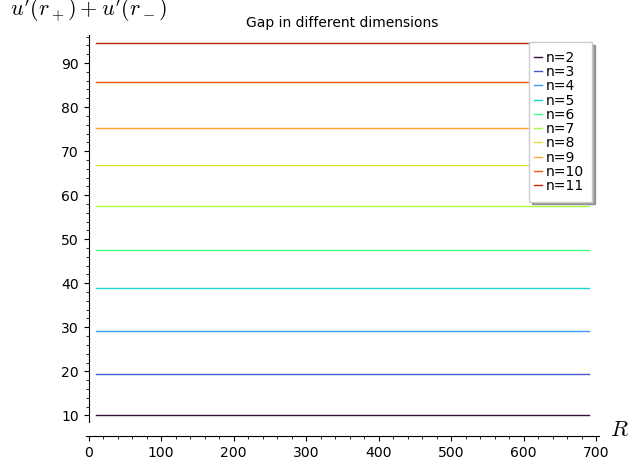

In [125]:
from sage.plot.colors import colormaps

N = len(v_gap)
cmap = colormaps.turbo
colores = [tuple(list(cmap(i/N))[:3])for i in range(N)]

pts = []
G = Graphics()

for n in range(0,10):
    pts.append( sorted(zip(vector_rango[:],[ gapatr for gapatr in v_gap[n][:]])) )         # sort by r just in case
    G += list_plot(pts[n], plotjoined=True,title="Gap in different dimensions", legend_label= "n={}".format(n+2),color=colores[n],
              axes_labels=['$R$', '$u\'(r_+)+u\'(r_-)$'])
G.show()

In [17]:
for i in range(0,10):
    print("n=",i+2)
    print("gap=",v_gap[i][-1])
    print("gap/n=",v_gap[i][-1]/RR(cosh(3)))

n= 2
gap= 10.094991467185617
gap/n= 1.0027145797524106
n= 3
gap= 19.439718226688687
gap/n= 1.9309069210747667
n= 4
gap= 29.097936540211844
gap/n= 2.8902377287214356
n= 5
gap= 38.947531049949106
gap/n= 3.868577537295466
n= 6
gap= 47.49172933890796
gap/n= 4.717255044798416
n= 7
gap= 57.436541744348325
gap/n= 5.705052649605876
n= 8
gap= 66.86416649295354
gap/n= 6.641479076372987
n= 9
gap= 75.34856283436201
gap/n= 7.484216580370113
n= 10
gap= 85.65711777897684
gap/n= 8.508143977708054
n= 11
gap= 94.58606308818102
gap/n= 9.395037609312775


# Funciones para hacer las gráficas

In [87]:
vector_rango = [i for i in Rango]

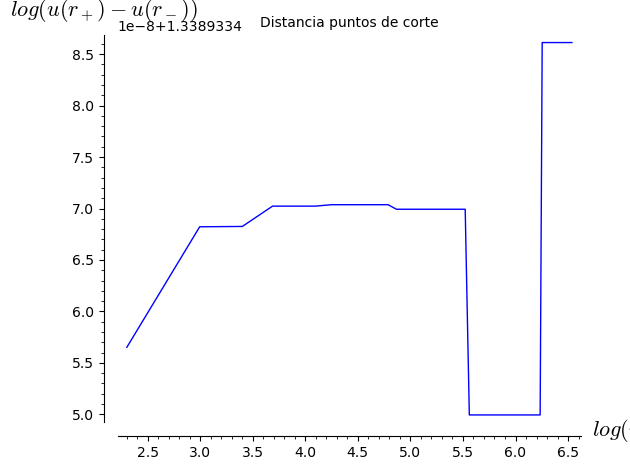

In [88]:
# t_full, u_full assumed to exist
pts = sorted(zip(np.log(vector_rango),np.log(distancia_cortes_lineal)))              # sort by r just in case
G = list_plot(pts, plotjoined=True, title="Distancia puntos de corte",
              axes_labels=['$log(r)$', '$log(u(r_+)-u(r_-))$'])
G.show()

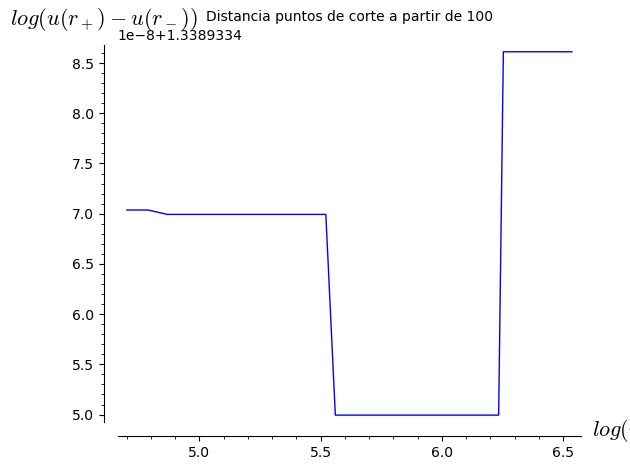

In [89]:
# t_full, u_full assumed to exist
pts = sorted(zip(np.log(vector_rango[10:]),np.log(distancia_cortes_lineal[10:])))              # sort by r just in case
G = list_plot(pts, plotjoined=True, title="Distancia puntos de corte a partir de 100",
              axes_labels=['$log(r)$', '$log(u(r_+)-u(r_-))$'])
G.show()

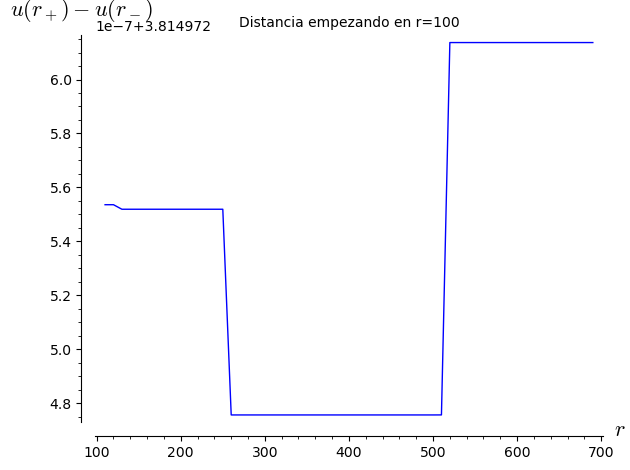

In [90]:
# t_full, u_full assumed to exist
pts = sorted(zip(vector_rango[10:],distancia_cortes_lineal[10:]))              # sort by r just in case
G = list_plot(pts, plotjoined=True,title="Distancia empezando en r=100",
              axes_labels=['$r$', '$u(r_+)-u(r_-)$'])
G.show()

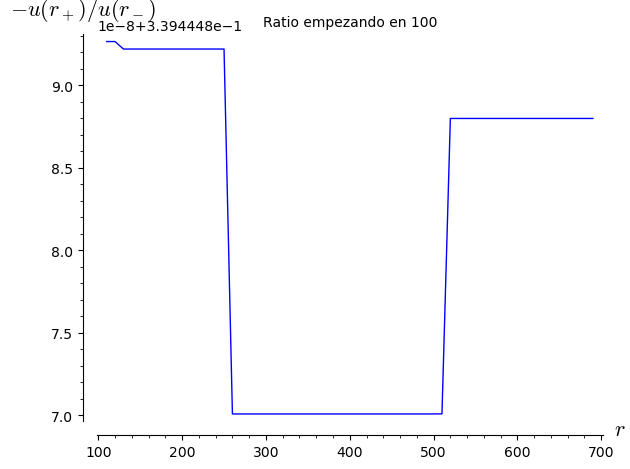

In [91]:
# t_full, u_full assumed to exist
pts = sorted(zip(vector_rango[10:],ratio_lineal[10:]))              # sort by r just in case
G = list_plot(pts, plotjoined=True,title="Ratio empezando en 100",
              axes_labels=['$r$', '$-u(r_+)/u(r_-)$'])
G.show()

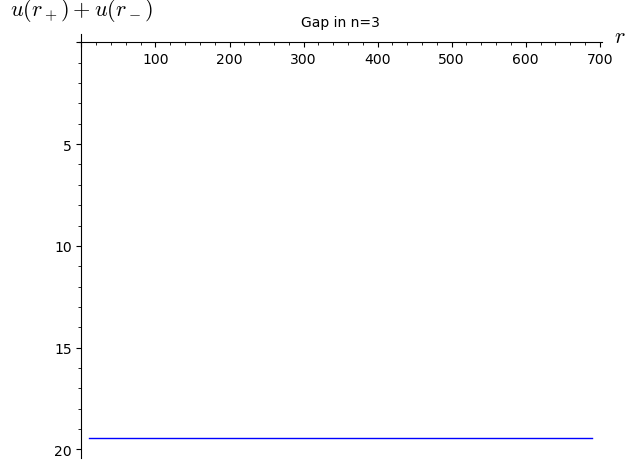

In [98]:
# t_full, u_full assumed to exist
pts = sorted(zip(vector_rango[:],[i for i in gap_lineal[:]]))              # sort by r just in case
G = list_plot(pts, plotjoined=True,title="Gap in n=3",ymin=20, ymax=0,
              axes_labels=['$r$', '$u(r_+)+u(r_-)$'])
G.show()

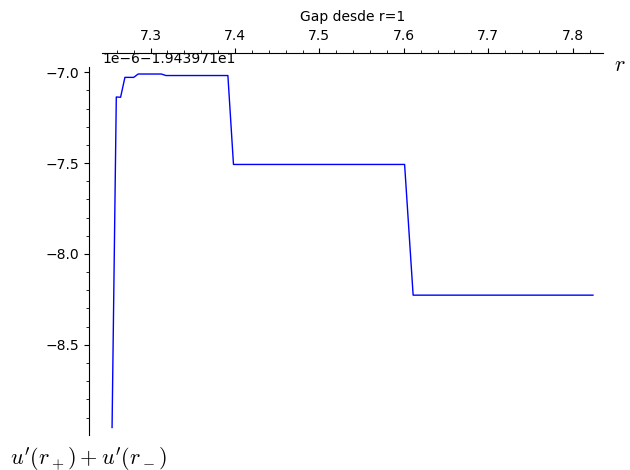

In [85]:
pts = sorted(zip(vector_rango[0:],[-i for i in gap_lineal[0:]]))              # sort by r just in case
G = list_plot(pts, plotjoined=True,title="Gap desde r=1", 
              axes_labels=['$r$', '$u\'(r_+)+u\'(r_-)$'])
G.show()

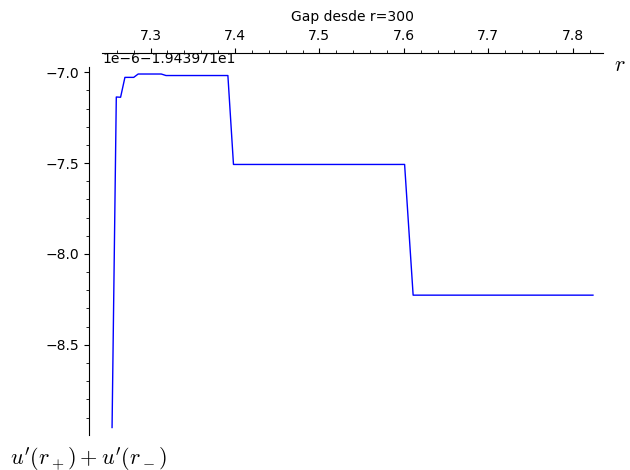

In [86]:
pts = sorted(zip(vector_rango[:],[-i for i in gap_lineal[:]]))              # sort by r just in case
G = list_plot(pts, plotjoined=True,title="Gap desde r=300", 
              axes_labels=['$r$', '$u\'(r_+)+u\'(r_-)$'])
G.show()

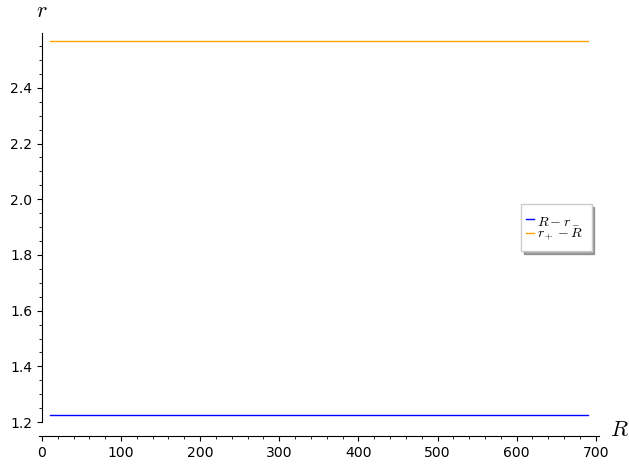

In [94]:
#Puntos de corte
vector_rango = [i for i in Rango]

r_minus = [-soluciones_lineal[i][0][0]+vector_rango[i] for i in range(len(soluciones_lineal))]
r_plus = [soluciones_lineal[i][0][-1]-vector_rango[i] for i in range(len(soluciones_lineal))]


pts_minus = sorted(zip(vector_rango,r_minus))           
pts_plus = sorted(zip(vector_rango,r_plus))              # sort by r just in case

G = list_plot(pts_minus, plotjoined=True, legend_label='$R-r_-$' , axes_labels=['$R$', '$r$'])
H =  list_plot(pts_plus, plotjoined=True, legend_label='$r_+-R$' ,color="orange", axes_labels=['$R$', '$r$'])
G+H

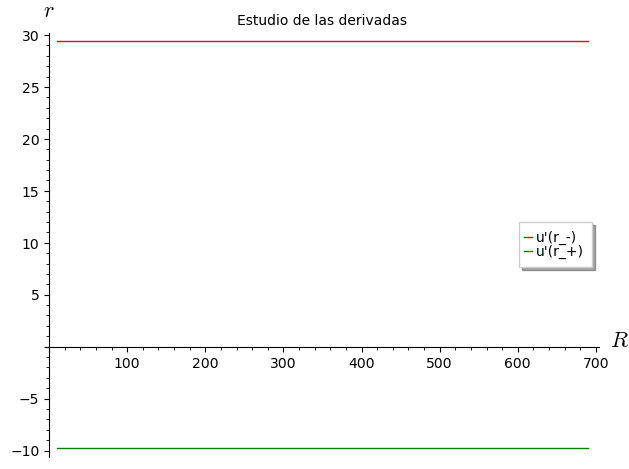

In [97]:
#Puntos de corte
vector_rango = [i for i in Rango]

upr_minus = [soluciones_lineal[i][2][0] for i in range(len(soluciones_lineal))]
upr_plus = [soluciones_lineal[i][2][-1] for i in range(len(soluciones_lineal))]


pts_minus = sorted(zip(vector_rango,upr_minus))           
pts_plus = sorted(zip(vector_rango,upr_plus))              # sort by r just in case

G = list_plot(pts_minus, plotjoined=True,  axes_labels=['$R$', '$r$'], legend_label='u\'(r_-)',color= "red", title="Estudio de las derivadas")
H =  list_plot(pts_plus, plotjoined=True,  axes_labels=['$R$', '$r$'],legend_label='u\'(r_+)',color= "green")
G+H

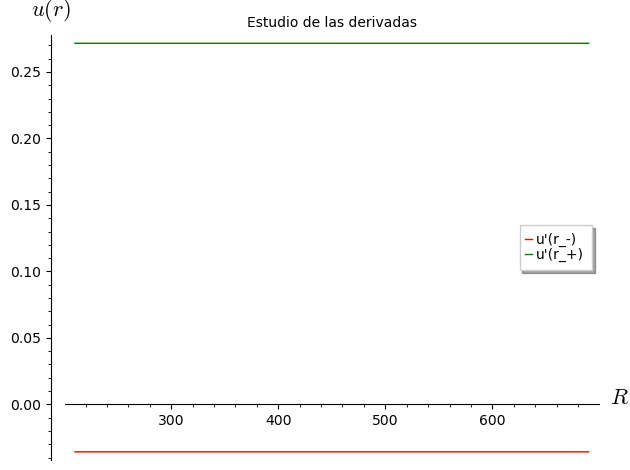

In [96]:
#Puntos de corte
vector_rango = [i for i in Rango[20:]]

upr_minus = [soluciones_lineal[i][1][0] for i in range(len(soluciones_lineal[20:]))]
upr_plus = [soluciones_lineal[i][1][-1] for i in range(len(soluciones_lineal[20:]))]


pts_upr_minus = sorted(zip(vector_rango,upr_minus))           
pts_upr_plus = sorted(zip(vector_rango,upr_plus))              # sort by r just in case

G = list_plot(pts_upr_minus, plotjoined=True,  axes_labels=['$R$', '$u(r)$'], legend_label='u\'(r_-)',color= "red", title="Estudio de las derivadas")
H =  list_plot(pts_upr_plus, plotjoined=True,  axes_labels=['$R$', '$u(r)$'],legend_label='u\'(r_+)',color= "green")
G+H

## Study of the convergence of solutions

In [67]:
vector_puntos_sol = transformar_grafica(Rango, soluciones_lineal)

In [68]:
import numpy as np
import plotly.graph_objects as go

# puntos = [(x,y,z), ...]
P = np.array(vector_puntos_sol[::], dtype=float)
x, y, z = P[:,0], P[:,1], P[:,2]


fig = go.Figure(
    data=[go.Scatter3d(x=x, y=y, z=z, mode='markers',
                       marker=dict(size=2, opacity=0.8))]
)
fig.update_layout(scene_aspectmode='data')


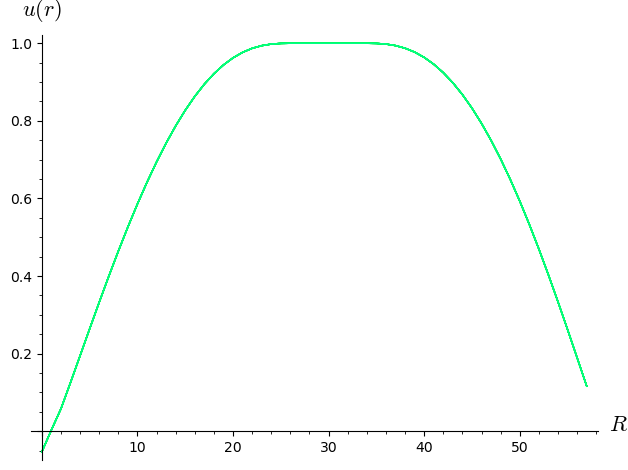

In [68]:
Graficas = list_plot(soluciones_lineal[20][1], plotjoined=True,  axes_labels=['', '$u_R(r)$'])
colores = rainbow(len(soluciones_lineal))
for i in range(21, 30):#len(soluciones_lineal[:30])):
    Graficas += list_plot(soluciones_lineal[i][1], plotjoined=True,color= colores[i] ,axes_labels=['$R$', '$u(r)$'])
show(Graficas)

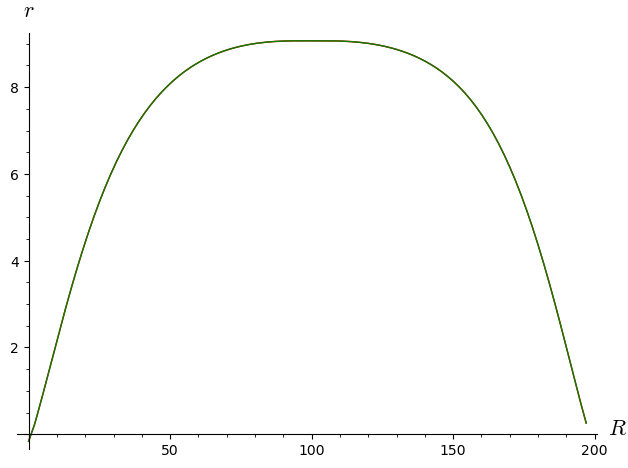

In [70]:
G = list_plot(soluciones_lineal[0][1], plotjoined=True, color = 'pink', axes_labels=['$R$', '$r$'])
H = list_plot(soluciones_lineal[5][1], plotjoined=True,  color='red',axes_labels=['$R$', '$r$'])
F = list_plot(soluciones_lineal[30][1], plotjoined=True,  color= 'green',axes_labels=['$R$', '$r$'])

G+H+F

In [71]:
r = var('r')
a, b =  var('a b')
# We define the initial values as a symbolic thing
M = var('M')+1
R = var('R')
f= simplify(1/2+a*cosh(r)+b*(-arctanh(1/cosh(r))+cosh(r))/cosh(r))
#f = (1/2+b) + cosh(r)*(a-b*arctanh(1/cosh(r)))


Vemos como es la función

In [44]:
f

a*cosh(r) - b*(arctanh(1/cosh(r)) - cosh(r))/cosh(r) + 1/2

Sustituímos en el caso de $r = R$

In [45]:
f_R = f.substitute({r: R})
f_R

a*cosh(R) - b*(arctanh(1/cosh(R)) - cosh(R))/cosh(R) + 1/2

In [46]:
df_R = diff(f,r).substitute({r: R})

Encontramos el caso de que hay un maximo en $r=R$ y $u(R)=M$

In [47]:

Sol_f = solve([df_R== 0,f_R==M],a,b)

Sustituímos estas variables en la ecuación original $f$

In [48]:

f_ic = simplify(f.subs(Sol_f))
f_ic

-1/2*(((2*M + 1)*cosh(R)^2 - 2*M - 1)*arctanh(1/cosh(R)) + (2*M + 1)*cosh(R))*cosh(r)/(cosh(R)^4 - 2*(cosh(R)^3 - cosh(R))*arctanh(1/cosh(R)) - 2*cosh(R)^2) - 1/2*((2*M + 1)*cosh(R)^3 - (2*M + 1)*cosh(R))*(arctanh(1/cosh(r)) - cosh(r))/((cosh(R)^3 - 2*(cosh(R)^2 - 1)*arctanh(1/cosh(R)) - 2*cosh(R))*cosh(r)) + 1/2

In [49]:
simplify(diff(f_ic,r,2)+cosh(r)/sinh(r)*diff(f_ic,r)-2*f_ic)

1/2*(((2*M + 1)*cosh(R)^2 - 2*M - 1)*arctanh(1/cosh(R)) + (2*M + 1)*cosh(R))*cosh(r)/(cosh(R)^4 - 2*(cosh(R)^3 - cosh(R))*arctanh(1/cosh(R)) - 2*cosh(R)^2) - 1/2*((((2*M + 1)*cosh(R)^2 - 2*M - 1)*arctanh(1/cosh(R)) + (2*M + 1)*cosh(R))*sinh(r)/(cosh(R)^4 - 2*(cosh(R)^3 - cosh(R))*arctanh(1/cosh(R)) - 2*cosh(R)^2) + ((2*M + 1)*cosh(R)^3 - (2*M + 1)*cosh(R))*(sinh(r)/((1/cosh(r)^2 - 1)*cosh(r)^2) - sinh(r))/((cosh(R)^3 - 2*(cosh(R)^2 - 1)*arctanh(1/cosh(R)) - 2*cosh(R))*cosh(r)) - ((2*M + 1)*cosh(R)^3 - (2*M + 1)*cosh(R))*(arctanh(1/cosh(r)) - cosh(r))*sinh(r)/((cosh(R)^3 - 2*(cosh(R)^2 - 1)*arctanh(1/cosh(R)) - 2*cosh(R))*cosh(r)^2))*cosh(r)/sinh(r) - 1/2*((2*M + 1)*cosh(R)^3 - (2*M + 1)*cosh(R))*(1/((1/cosh(r)^2 - 1)*cosh(r)) - 2*sinh(r)^2/((1/cosh(r)^2 - 1)*cosh(r)^3) + 2*sinh(r)^2/((1/cosh(r)^2 - 1)^2*cosh(r)^5) - cosh(r))/((cosh(R)^3 - 2*(cosh(R)^2 - 1)*arctanh(1/cosh(R)) - 2*cosh(R))*cosh(r)) + 3/2*((2*M + 1)*cosh(R)^3 - (2*M + 1)*cosh(R))*(arctanh(1/cosh(r)) - cosh(r))/((cosh(R)^3

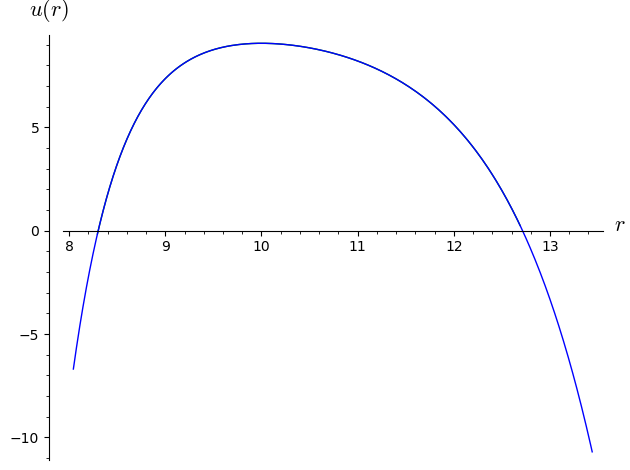

In [72]:
r = var('r')
sol_ana = (-arctanh(1/cosh(10)) - cosh(10) + arctanh(1/cosh(10))*cosh(10)**2)*cosh(r)+cosh(3) + cosh(10)**2 - arctanh(1/cosh(r))* ( cosh(10)**2) * cosh(r) 
ptos = sorted(zip(soluciones_lineal[0][0],soluciones_lineal[0][1]))
G = list_plot(ptos, plotjoined=True,color= "green" ,axes_labels=['$r$', '$u(r)$'])
H = plot(sol_ana,xmin = soluciones_lineal[0][0][0]-0.25,xmax = soluciones_lineal[0][0][-1]+0.75 )
show(G+H)

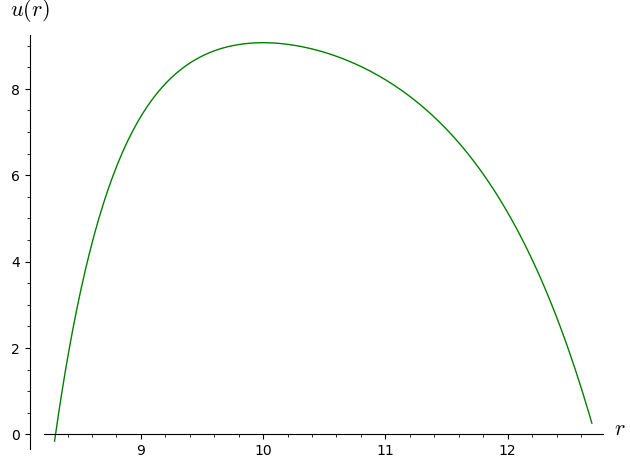

In [73]:
show(G)

## Solucion del problema de $r=700$
Hacemos un cambio de variable: 
$
s = \tanh(r).
$
Entonces tenemos que $\frac{ds}{dr} = 1-\tanh^2(r) = 1-s^2.$ Luego suponemos que, 
* $u'(r)= \frac{du}{dr} =\frac{du}{ds} \frac{ds}{dr}= u_s(1-s^2)$
* $u''(r)= \frac{d^2u}{dr^2} =\frac{d}{dr}\left( \frac{du}{dr} \right) = \frac{d}{dr}\left(u_s(1-s^2) \right) =  u_{ss}(1-s^2)^2-u_{s}2s(1-s^2)$
* $\operatorname{cotanh(r)}= \frac{1}{s}$

Entonces, el sistema de ecuaciones original se transforma de la siguiente forma, 

$$
   \left\lbrace
\begin{aligned}
    y'_1(r)=&y_2(r),\\
    y'_2(r)=& \frac{1}{(1-s^2)^2}. \left( y_2 \frac{(1-s^2)}{s} \left(2 s^2-n+1\right) +n*y_1(r) - n*(M+1)\right).
\end{aligned}
\right.
$$


In [74]:
# Definición del sistema de ecuaciones de primer orden: Y = [u, w]
def sistema_serrin_reparam(s, Y):
    y1,y2 = Y
    return [
        y2,          # y_1'(r) = y_2(r)
        (y2 *(1-s^2)/s*(2*s*s-n+1)+n*y1-n*(U0+1))/(1-s^2)^2]      # y_2'(r)=  - (n-1)*coth(r)*y_2(r) + n*y_1(r) - n*(cosh(3)-1+1)


In [79]:

# Parámetro de la ecuación 
n = 2

# Condiciones iniciales 
U0 =RR(cosh(3)-1)
W0 = Integer(0.0)
# En este caso empieza en 1 y va hasta 400 con pasos de 1. 
Rango = srange(0.99999999,0.99999999999,0.0000000001)
ratio_lineal, soluciones_lineal, distancia_cortes_lineal, gap_lineal= analisis_asintotico(n,U0, W0, Rango,sistema_serrin_reparam)

0.999999990000000
0.999999990100000
0.999999990200000
0.999999990300000
0.999999990400000
0.999999990500000
0.999999990600000
0.999999990700000
0.999999990800000
0.999999990900000
0.999999991000000
0.999999991100000
0.999999991200000
Error in  0.999999991200000
0.999999991300000
Error in  0.999999991300000
0.999999991400000
Error in  0.999999991400000
0.999999991500000
Error in  0.999999991500000
0.999999991600000
Error in  0.999999991600000
0.999999991700000
Error in  0.999999991700000
0.999999991800000
Error in  0.999999991800000
0.999999991900000
Error in  0.999999991900000
0.999999992000000
Error in  0.999999992000000
0.999999992100000
Error in  0.999999992100000
0.999999992200000
Error in  0.999999992200000
0.999999992300000
Error in  0.999999992300000
0.999999992400000
Error in  0.999999992400000
0.999999992500000
Error in  0.999999992500000
0.999999992600000
Error in  0.999999992600000
0.999999992700000
Error in  0.999999992700000
0.999999992800000
Error in  0.999999992800000
0.

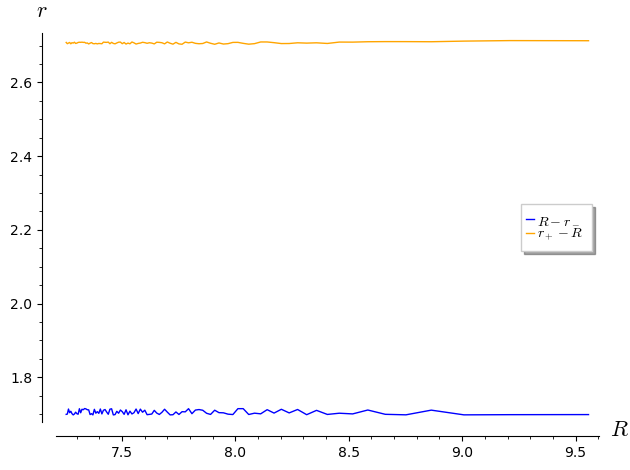

In [75]:
vector_rango = [arctanh(i) for i in Rango]

r_minus = [-arctanh(soluciones_lineal[i][0][0])+vector_rango[i] for i in range(len(soluciones_lineal))]
r_plus = [arctanh(soluciones_lineal[i][0][-1])-vector_rango[i] for i in range(len(soluciones_lineal))]


pts_minus = sorted(zip(vector_rango,r_minus))           
pts_plus = sorted(zip(vector_rango,r_plus))              # sort by r just in case

G = list_plot(pts_minus, plotjoined=True, legend_label='$R-r_-$' , axes_labels=['$R$', '$r$'])
H =  list_plot(pts_plus, plotjoined=True, legend_label='$r_+-R$' ,color="orange", axes_labels=['$R$', '$r$'])
G+H

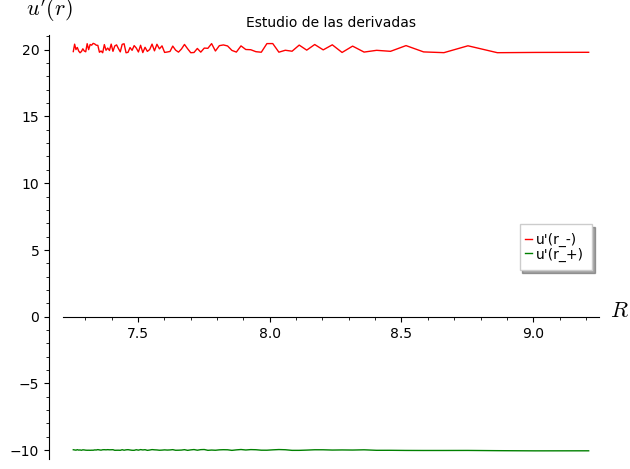

In [78]:
#Puntos de corte
vector_rango = [arctanh(i) for i in Rango[:]]

upr_minus = [soluciones_lineal[j][2][0]*(1-soluciones_lineal[j][0][0]^2) for j in range(1,len(soluciones_lineal[:]))]
upr_plus = [soluciones_lineal[j][2][-1]*(1-soluciones_lineal[j][0][-1]^2) for j in range(1,len(soluciones_lineal[:]))]


pts_upr_minus = sorted(zip(vector_rango,upr_minus))           
pts_upr_plus = sorted(zip(vector_rango,upr_plus))              # sort by r just in case

G = list_plot(pts_upr_minus, plotjoined=True,  axes_labels=['$R$', '$u\'(r)$'], legend_label='u\'(r_-)',color= "red", title="Estudio de las derivadas")
H =  list_plot(pts_upr_plus, plotjoined=True,  axes_labels=['$R$', '$u\'(r)$'],legend_label='u\'(r_+)',color= "green")
G+H

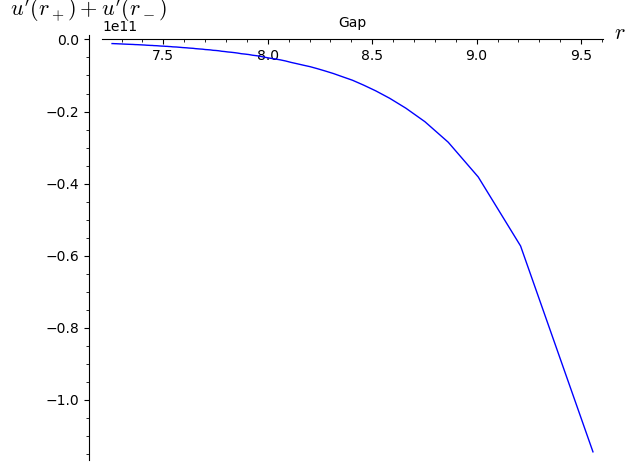

In [70]:
pts = sorted(zip(vector_rango[:],[i for i in gap_lineal[:]]))              # sort by r just in case
G = list_plot(pts, plotjoined=True,title="Gap", 
              axes_labels=['$r$', '$u\'(r_+)+u\'(r_-)$'])
G.show()

# Buscando otra f(x)

In [275]:
#Dimension
n = 2
#Variable de distancia
r , s= var('r s')
#Variable de solución
v = function('v')(r,s,c1,c2)
c1, c2 = var('c_1 c_2')

M = (cosh(3)+1)


v = ln(cosh(x))-cosh(x)+cosh(3)+1

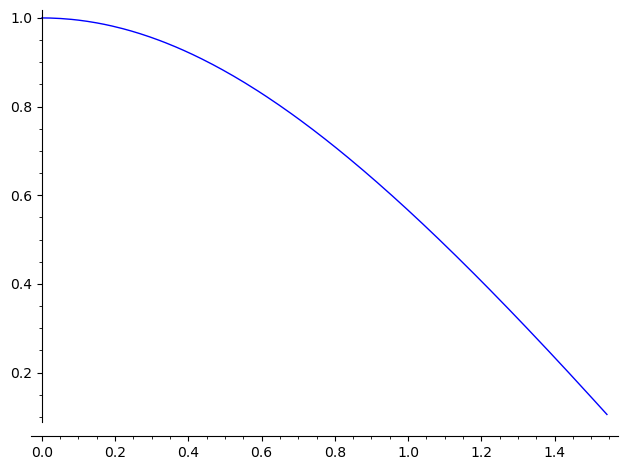

In [321]:
v = ln(1/cosh(x))+1
plot(v,xmin=0,xmax=cosh(1))

In [302]:
v.diff()

-cosh(x)*log(cosh(x)) - sinh(x)^2/cosh(x)

In [304]:
simplify(v.diff().diff())

-log(cosh(x))*sinh(x) + sinh(x)^3/cosh(x)^2 - 3*sinh(x)

In [316]:
simplify(diff(v,2) + 2*cosh(x)/sinh(x)*diff(v)+ e^(2*v)+(1))

sinh(x)^2/cosh(x)^2 + e^(2*cosh(1))/cosh(x)^2 - 2

Si tenemos $f(x)=e^{2x-2M}+(n-1)$ entonces la función $u(x)= \ln(\frac{1}{\cosh(x)})+M$ será una solución para la ecuación, 
$$
u''(x)+(n-1)\frac{\cosh(x)}{\sinh(x)}u'(x)+e^{2u-2M}+(n-1)=0,
$$
con condiciones iniciales $u(0)= 1$ y $u'(0)= 0$.

Traducirlo a un sistema de ecuaciones para poder correr Runge-Kutta: 
$$
   \left\lbrace
\begin{aligned}
    y'_1(r)=&y_2(r),\\
    y'_2(r)=& - (n-1)*coth(r)*y_2(r) -e^{2u-2M}-(n-1).
\end{aligned}
\right.
$$


Imponemos las condiciones iniciales genéricas $u(R)= 1$ y $u'(R)= 0$ para $R \in [0,+\infty)$. 


In [5]:
# Definición del sistema de ecuaciones de primer orden: Y = [u, w]
def sistema_e(r, Y):
    y1,y2 = Y
    n=2
    return [
        y2,          # y_1'(r) = y_2(r)
         - (n-1)*coth(r)*y2 -e^(2*y1-2)-(n-1)]      # y_2'(r)=  - (n-1)*coth(r)*y_2(r) + n*y_1(r) - n*(cosh(3)+1)


In [6]:

# Parámetro de la ecuación 
n = 2

# Condiciones iniciales 
U0 =RR(1)
W0 = Integer(0.0)
# En este caso empieza en 1 y va hasta 400 con pasos de 1. 
Rango = srange( 1,600,10)
ratio_e, soluciones_e, distancia_cortes_e, gap_e = analisis_asintotico(n,U0, W0, Rango,sistema_e)

In [7]:
superficie_soluciones = []
vector_rango = [i for i in Rango]
for i in range(0,len(Rango)):
    R = vector_rango[i]
    for r in soluciones_e[i][0]:
        for ux in soluciones_e[i][1]:
            superficie_soluciones.append([R,r,ux])

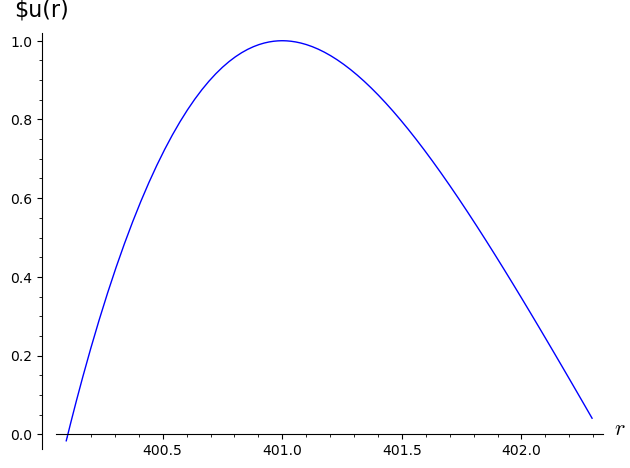

In [11]:
# t_full, u_full assumed to exist
K = 40
pts = sorted(zip(soluciones_e[K][0],soluciones_e[K][1]))              # sort by r just in case
G = list_plot(pts, plotjoined=True,
              axes_labels=['$r$', '$u(r)'])
G.show()

In [17]:
G_distancia_log_log, G_ratio, G_gap = graficas(rango= Rango, ratio =ratio_e,  distancia_cortes = distancia_cortes_e, gap = gap_e)

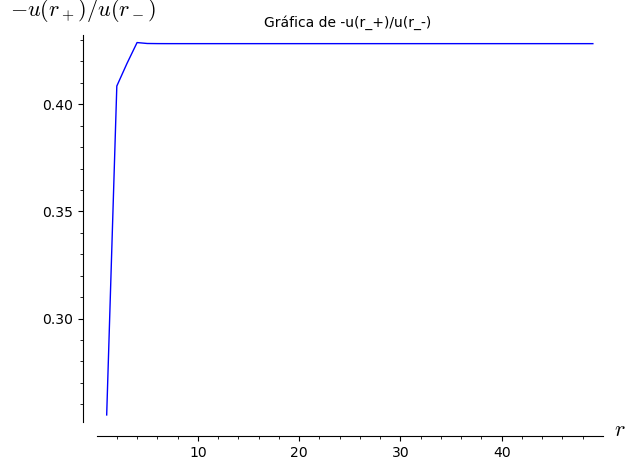

In [18]:
G_ratio.show()

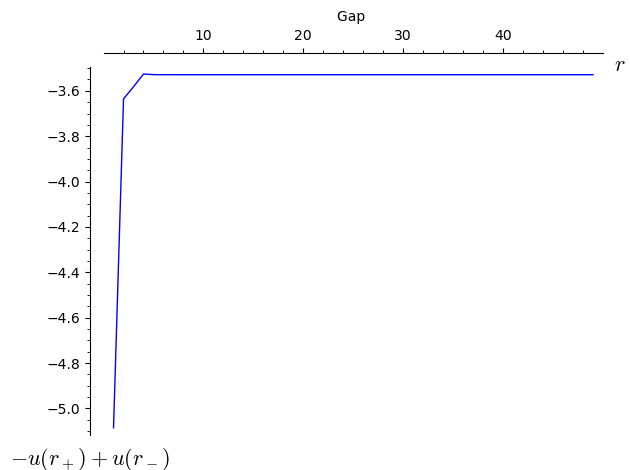

In [19]:
G_gap.show()

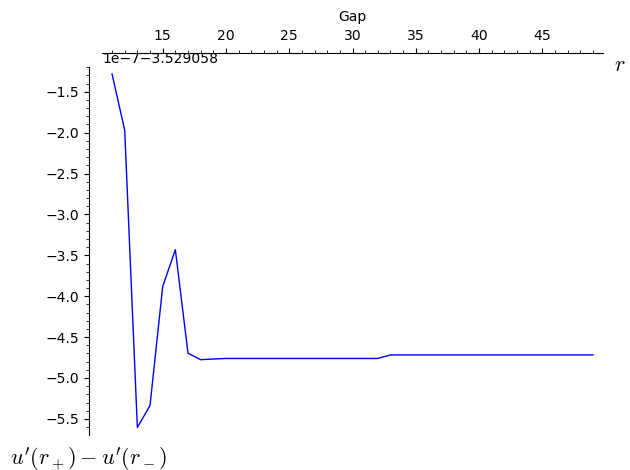

In [20]:
vector_rango = [i for i in Rango]
# t_full, u_full assumed to exist
pts = sorted(zip(vector_rango[10:],gap_e[10:]))              # sort by r just in case
G = list_plot(pts, plotjoined=True,title="Gap", 
              axes_labels=['$r$', '$u\'(r_+)-u\'(r_-)$'])
G.show()

# Prueba $f(r) = (r-k)(1-\ln(r-k)^2- n\ln(r-k))$

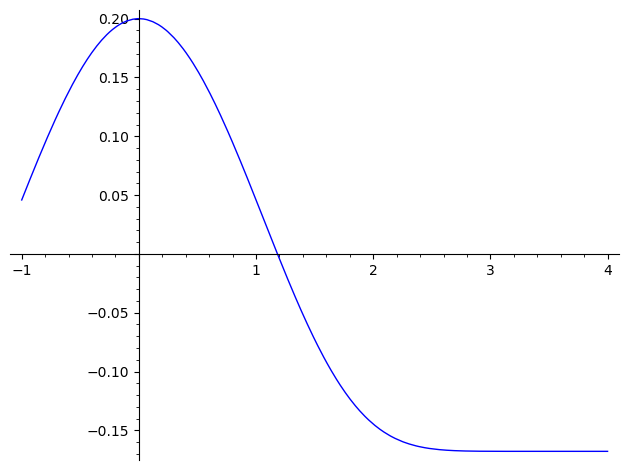

In [35]:

k = (-1/e +0.2)
v = e^(-cosh(x))+ k
plot(v,xmin=-1,xmax=4)

In [ ]:
U0 =RR(0.2)
ext = 2
t_ln, u_ln , pu_ln= solve_problem(r0=RR(650),Y0= [U0,0],extremo=ext, sys=sistema_ln)
pts = sorted(zip(t_ln,u_ln) )             # sort by r just in case
G = list_plot(pts, plotjoined=True, ymin=0,
              axes_labels=['$r$', '$u(r)$'])
G.show()

In [40]:
simplify(diff(v,2)+cosh(x)/sinh(x)* diff(v)+(v-k)*(1-2*ln(v-k)-ln(v-k)^2))

e^(-cosh(x))*sinh(x)^2 - (cosh(x)^2 - 2*cosh(x) - 1)*e^(-cosh(x)) - 2*cosh(x)*e^(-cosh(x))

In [18]:
# Definición del sistema de ecuaciones de primer orden: Y = [u, w]
def sistema_ln(r, Y):
    y1,y2 = Y
    n=2
    k = -RR(1/e)+0.3
    return [
        y2,          # y_1'(r) = y_2(r)
         - (n-1)*coth(r)*y2 -(y1-k)*(1-n*ln(y1-k)-ln(y1-k)^2)]      # y_2'(r)=  - (n-1)*coth(r)*y_2(r) + f(y_1)


In [58]:

# Condiciones iniciales 
U0 =RR(0.3)
W0 = Integer(0.0)
# En este caso empieza en 1 y va hasta 400 con pasos de 1. 
Rango = srange( 1,700,50)


In [59]:

ratio_ln, soluciones_ln, distancia_cortes_ln, gap_ln= analisis_asintotico(n,U0, W0, Rango,sistema_ln)

In [ ]:
G_distancia_log_log, G_ratio, G_gap = graficas(rango= Rango, ratio =ratio_ln,  distancia_cortes = distancia_cortes_ln, gap = gap_ln)

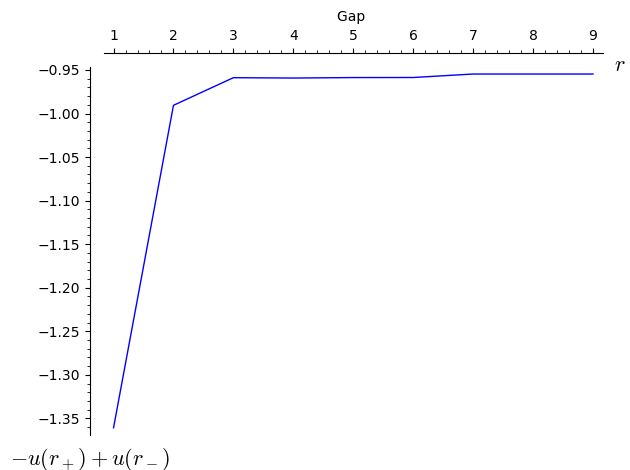

In [61]:
G_gap.show()

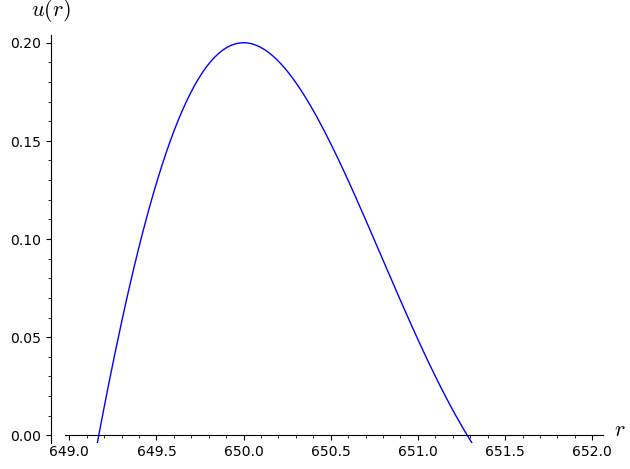

In [ ]:
U0 =RR(0.2)
ext = 2
t_ln, u_ln , pu_ln= solve_problem(r0=RR(650),Y0= [U0,0],extremo=ext, sys=sistema_ln)
pts = sorted(zip(t_ln,u_ln) )             # sort by r just in case
G = list_plot(pts, plotjoined=True, ymin=0,
              axes_labels=['$r$', '$u(r)$'])
G.show()

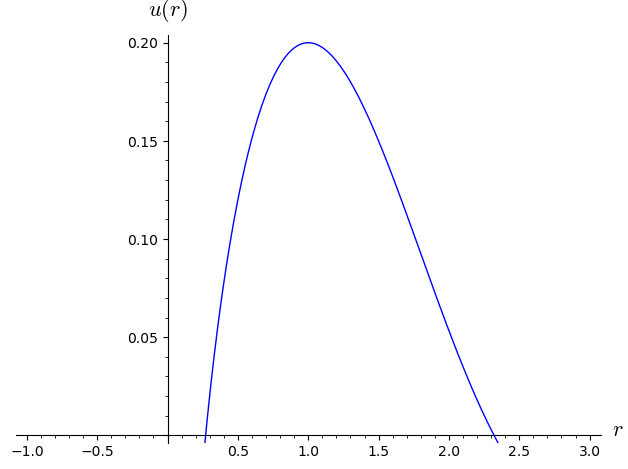

In [46]:
pts = sorted(zip(t_ln, u_ln ) )             # sort by r just in case
G = list_plot(pts, plotjoined=True, ymin=0,xmin = 1-ext, xmax =1+ext,
              axes_labels=['$r$', '$u(r)$'])
G.show()